# QST-CGAN

## - Demonstrating simple use of the QST-CGAN code

Shahnawaz Ahmed, Chalmers University of Technology, Sweden  
Email: shahnawaz.ahmed95gmail.com  
GitHub: quantshah

### Introduction

Quantum State Tomography is the process of determining an unknown quantum state by making measurements on the system and using the measurement data to reconstruct the density matrix of the state. In this notebook, we will use QuTiP for Quantum State Tomography of a cavity and show how to use a simple conditional generative adversarial neural network for reconstruction of a cat state. The data is from a "displace-and-measure" method and we consider the Husimi $Q$ function (see [1]).

Here we focus on comparing the choice of measurement settings (displacements) for the Husimi $Q$ function in a $32 \times 32$ grid (1024 data points).

## References
[1] Shahnawaz Ahmed, Carlos Sánchez Muñoz, Franco Nori, Anton Frisk Kockum. "Quantum State Tomography with Conditional Generative Adversarial Networks." https://arxiv.org/abs/2008.03240

In [11]:
# imports 

import numpy as np
from qutip import fidelity, ket2dm
from qutip.visualization import plot_wigner, hinton, plot_wigner_fock_distribution

import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import animation

from qst_cgan.ops import expect as tf_expect, wigner_ops
from qst_cgan.ops import (random_alpha, dm_to_tf, husimi_ops, tf_to_dm, clean_cholesky, density_matrix_from_T,
                          batched_expect, convert_to_real_ops, convert_to_complex_ops)

from qst_cgan.train_gan import train_GAN
from qst_cgan.states import cat

from qst_cgan.ops import wigner_ops
from qst_cgan.models import Generator, Expectation, DensityMatrix, GeneratorSimple



import tensorflow as tf
import os


from IPython.display import clear_output

tf.keras.backend.set_floatx('float64')
os.environ["CUDA_VISIBLE_DEVICES"] = ""



### Optical quantum states in the fock basis - Cat state

In the fock basis, we can describe optical quantum states as $|\psi \rangle = \sum_n^{N_{cut}}p_n |n \rangle$, where $N_{cut}$ is the photon number cutoff which truncates the Hilbert space and $|{p_n}|^2$ is the probability of observing $n$ photons. The vaccum state $\psi_{vac} = |0 \rangle$ or a superposition of fock states containing two and three photons $\psi_{fock} = \frac{1}{\sqrt{2}}(|2 \rangle + |3 \rangle$ are some examples of simple optical quantum states. The coherent state is a displaced fock state $\psi_{\texttt{coherent}(\alpha)} = D(\alpha) |0 \rangle$ and a superposition of two such coherent states is defined as a CAT state,  
$$\psi_{\texttt{CAT}(\alpha)} = \frac{1}{N}[{\psi_{\texttt{coherent}}(\alpha) + \psi_{\texttt{coherent}}(-\alpha)}]$$ where $N$ is the normalization.

### Cat state

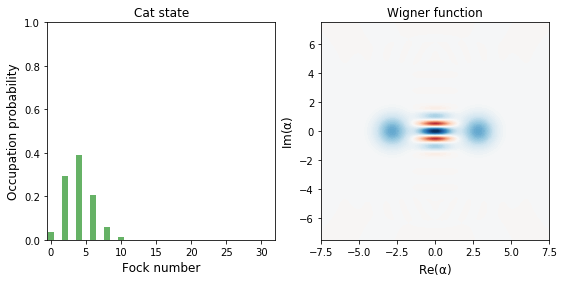

In [12]:
hilbert_size = 32
rho = ket2dm(cat(hilbert_size, 2, 0, 0))

fig, ax = plot_wigner_fock_distribution(rho, figsize=(9, 4))
ax[0].set_title("Cat state")
plt.show()

### Displacement operation

The measurement obervables considered here are photon number statistics (see [1, 2]). This type of measurement simply relies on finding the probability of observing a certain number of photons in the cavity, i.e., measuring the photon number operator (occupation) $|n \rangle  \langle n|$ after displacing the state by applying the displacement operator $$ D(\beta) = e^{\beta a^{\dagger} - \beta^*a}.$$

### Displace and measure - the Husimi Q function

The Husimi Q function represents just one level of the generalized Q function measurement (n=0). As such, in case of such a measurement for tomography, we might need to provide more datapoints (multiple $\beta$ values). Here we consider a set of $\beta$ values generated in a 32 x 32 grid.

In [13]:
xvec =  np.linspace(-5, 5, 32)
yvec =  np.linspace(-3, 3, 32)

X, Y = np.meshgrid(xvec, yvec)
betas = ((X+1j*Y)).ravel()
num_points = len(betas)

# Data

The data is now the Husimi Q function values for the $1024$ selected $\beta$ values

In [14]:
ops = husimi_ops(hilbert_size, betas)
ops_batch = tf.convert_to_tensor([ops])
A = convert_to_real_ops(ops_batch)

rho_tf = dm_to_tf([rho])
x = batched_expect(ops_batch, rho_tf)

Text(0, 0.5, 'Im[$\\beta$]')

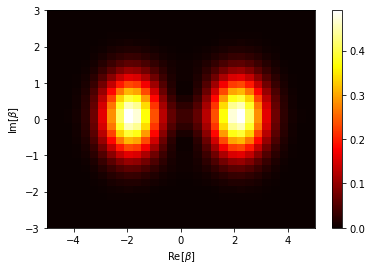

In [15]:
norm = colors.Normalize(0, np.max(x))
im = plt.pcolor(xvec, yvec, x.numpy().reshape((len(xvec), len(yvec))), cmap="hot", norm=norm)
plt.colorbar(im)
plt.xlabel(r"Re[$\beta$]")
plt.ylabel(r"Im[$\beta$]")

### Reconstruct the cat state density matrix from the Husimi Q function data

Note that for 10000 iterations (which reproduces Fig 3 (a) of [1]), it might take a couple of minutes to run.

In [16]:
# initial_learning_rate = 0.0002
# lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(initial_learning_rate,
#                                                              decay_steps=10000,
#                                                              decay_rate=0.96,
#                                                              staircase=False)

lr_schedule = 0.0002
gan_tol=0
max_iterations = 1000

states_list = []
fidelities_list = []

generator = Generator(hilbert_size, int(num_points), noise=0.)

fidel_gan, model_dm, states_gan = train_GAN(A, x, rho,
                                            tol=gan_tol,
                                            lam=1., gan_lam=1.,
                                            max_iterations=1000,
                                            lr=lr_schedule,
                                            generator = generator, states_list = states_list,
                                           fidelity_list= fidelities_list)

KeyboardInterrupt: 

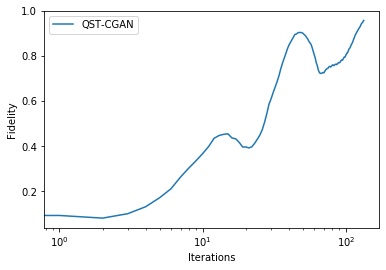

In [17]:
plt.semilogx(fidelities_list, label="QST-CGAN")
plt.xlabel("Iterations")
plt.ylabel("Fidelity")
plt.legend()
plt.show()

In [ ]:
gan_rho_reconstructed = states_list[-1]

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
plot_wigner(gan_rho_reconstructed, fig=fig, ax=ax[1])
plot_wigner(rho, fig=fig, ax=ax[0], cmap="RdBu")
hinton(gan_rho_reconstructed, ax=ax[2])

ax[0].set_title("Target state (Wigner)")
ax[1].set_title("Reconstructed state (QST-CGAN)(Wigner)")
ax[2].set_title("Reconstructed Density matrix (QST-CGAN)")
ax[2].set_xlabel("Reconstruction fidelity (QST-CGAN) {:2f}".format(fidelity(gan_rho_reconstructed, rho)), fontsize=13)

plt.show()

# QuTiP details

In [ ]:
qutip.about()